# Red or Green, What Coloured Cat Food does Mi Prefer?

A chi-squared analysis of cat food colour preference over 30 days.

## 1. Data Collection

The raw experimental data was recorded by hand on paper data sheets over 30 days (August–September 2024). Each day, Mi was presented with two bowls of kibble — one dyed red, one dyed green — and the colour he approached first was recorded as his preference. The original handwritten data sheets are photographed and available in the [DATA](https://github.com/vivianweidai/research/tree/main/20250225%20Catfood/DATA) folder.

The preference tallies were transcribed from these handwritten records into [catfood_summary.csv](https://github.com/vivianweidai/research/blob/main/20250225%20Catfood/OUTPUT/catfood_summary.csv).

## 2. Load and Inspect Data

We load the transcribed summary counts and verify the totals.

In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, warnings
from scipy.stats import chisquare, chi2

warnings.filterwarnings('ignore', message='.*findfont.*')
plt.rcParams.update({'font.family': 'serif',
                     'font.serif': ['Times New Roman', 'DejaVu Serif', 'serif'],
                     'mathtext.fontset': 'dejavuserif'})

df = pd.read_csv('https://raw.githubusercontent.com/vivianweidai/research/main/20250225%20Catfood/OUTPUT/catfood_summary.csv')
print(df.to_string(index=False) + f'\n\nTotal days: {df["days_preferred"].sum()}')

colour  days_preferred
   red              13
 green              17

Total days: 30


## 3. Visualize Preferences

A bar chart and pie chart show the distribution of Mi's colour preferences across all 30 trial days.

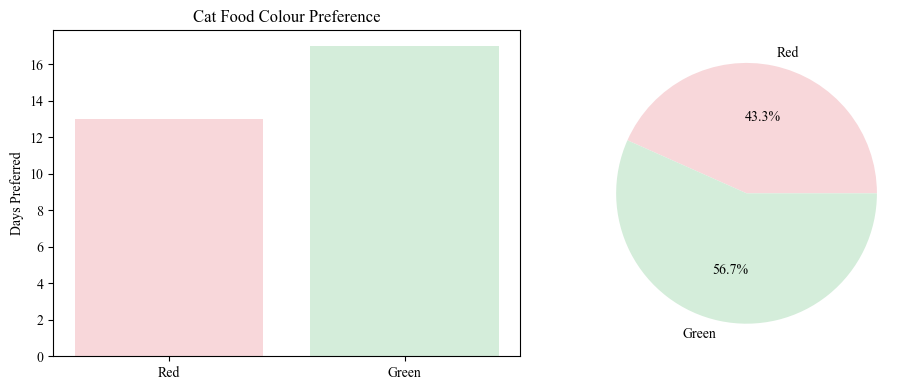

In [2]:
labels = df['colour'].str.capitalize()
values = df['days_preferred']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.bar(labels, values, color=['#f8d7da', '#d4edda'])
ax1.set(ylabel='Days Preferred', title='Cat Food Colour Preference')
ax2.pie(values, labels=labels, colors=['#f8d7da', '#d4edda'], autopct='%1.1f%%')
plt.tight_layout()
plt.savefig('catfood_preference.png', dpi=300, bbox_inches='tight')
plt.savefig('catfood_preference.svg', bbox_inches='tight')
plt.show()

## 4. Chi-Squared Test

We test whether Mi's observed preferences (13 red, 17 green) differ significantly from what we would expect under the null hypothesis of no colour preference (15 each).

In [3]:
observed = np.array(values)
expected = np.array([15, 15])
chi2_stat, p_val = chisquare(observed, f_exp=expected)
crit = chi2.ppf(0.95, df=1)

print(f'Observed:     Red = {observed[0]}, Green = {observed[1]}')
print(f'Expected:     Red = {expected[0]}, Green = {expected[1]}')
print(f'\nChi-squared:  {chi2_stat:.3f}')
print(f'p-value:      {p_val:.4f}')
print(f'Critical:     {crit:.3f} (α = 0.05, df = 1)')
print(f'\n{chi2_stat:.3f} < {crit:.3f} → fail to reject H₀')
print('Mi has no statistically significant colour preference.')

Observed:     Red = 13, Green = 17
Expected:     Red = 15, Green = 15

Chi-squared:  0.533
p-value:      0.4652
Critical:     3.841 (α = 0.05, df = 1)

0.533 < 3.841 → fail to reject H₀
Mi has no statistically significant colour preference.


## 5. Conclusion

The chi-squared statistic (0.533) falls well below the critical value (3.841), and the p-value indicates no significant evidence against the null hypothesis. We conclude that Mi enjoys his cat food equally regardless of whether it is dyed red or green.

---

<a href="https://colab.research.google.com/github/vivianweidai/research/blob/main/20250225%20Catfood/OUTPUT/catfood_analysis.ipynb"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab" style="vertical-align:middle;"></a>&nbsp;&nbsp;Try running this analysis yourself in Google Colab — no setup required.